Student Name :Diksha Ajay Sapale
Roll Number :cs48

Aim

To implement Principal Component Analysis (PCA) for dimensionality reduction on the Breast Cancer Wisconsin (Diagnostic) dataset, visualize the high-dimensional feature space in a reduced 2D plane, and evaluate its impact on classification performance.

## Objectives

1. To understand the concepts of dimensionality reduction, feature correlation, and Principal Component Analysis.

2. To preprocess, clean, and scale high-dimensional real-world data using StandardScaler.

3. To implement PCA using Python to compress feature dimensions from 30 continuous features down to 2 principal components.

4. To calculate and plot the explained variance ratio and cumulative explained variance.

5. To visualize the transformed 2D dataset and analyze class separability.

6. To evaluate and compare classification model performance (e.g., Logistic Regression) before and after applying PCA.

# Relevant Theory

### Support Vector Machine

Principal Component Analysis (PCA)Principal Component Analysis (PCA) is an unsupervised machine learning technique used for dimensionality reduction. It transforms a dataset containing a large set of correlated features into a smaller set of uncorrelated variables called Principal Components ($PCs$), while preserving as much data variance as possible.

Mathematical Steps:

1. Standardization: Scale each feature to have a mean of 0 ($\mu = 0$) and standard deviation of 1 ($\sigma = 1$).

2. Covariance Matrix: Compute the covariance matrix $C$ to quantify feature correlations:$$C = \frac{1}{n-1} X^T X$$

3. Eigen decomposition: Compute eigenvalues ($\lambda$) and eigenvectors ($v$) of matrix $C$:$$C v = \lambda v$$

    * Eigenvectors represent the direction of the principal axes.
    * Eigenvalues indicate the amount of variance along those axes.
4. Projection: Project original data $X$ onto top $k$ principal component directions $W$:$$X_{\text{pca}} = X \cdot W$$

###Dataset Information


1. Dataset Name: Breast Cancer Wisconsin (Diagnostic) Dataset

2. Kaggle Link: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

3. Classes: 2 binary classes (Malignant [$M$] and Benign [$B$])

4. Features: 30 continuous features computed from digitized images of fine needle aspirates (FNA) of a breast mass (e.g., radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, concavity_mean, etc.).

5. Non-Feature Columns: id (identifier) and Unnamed: 32 (empty column).

# Task 1: Import Libraries and Load Dataset

Import core Python libraries (numpy, pandas, matplotlib, seaborn, sklearn) and load data.csv obtained from Kaggle.

---

In [1]:
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Define the correct dataset URL for Breast Cancer Wisconsin (Diagnostic) from UCI repository
data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"
file_path = "data.csv"

# Define column names based on the UCI dataset description (32 columns)
column_names = [
    'id', 'diagnosis',
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]

# If data.csv exists, remove it to ensure a fresh download of the correct dataset
if os.path.exists(file_path):
    os.remove(file_path)
    print(f"Removed existing dataset at: {file_path}")

# Download the dataset
print(f"Downloading dataset from: {data_url}")
urllib.request.urlretrieve(data_url, file_path)

# Load dataset, specifying column names and no header as the file doesn't contain one
df = pd.read_csv(file_path, names=column_names, header=None)

# Display first few rows
display(df.head())

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Task 2: Explore the Dataset

Inspect missing values, view dataset summary statistics, check column data types, and inspect target class distributions (diagnosis).

In [ ]:
# 1. Inspect column data types and non-null counts
print("--- Dataset Info & Data Types ---")
df.info()

# 2. Check for missing values in each column
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

# 3. Summary statistics for numerical features
print("\n--- Summary Statistics ---")
display(df.describe())

# 4. Target class distribution ('diagnosis': 'M' = Malignant, 'B' = Benign)
print("\n--- Target Class Counts ('diagnosis') ---")
print(df['diagnosis'].value_counts())

print("\n--- Target Class Proportions (%) ---")
print(df['diagnosis'].value_counts(normalize=True) * 100)

--- Dataset Info & Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500



--- Target Class Counts ('diagnosis') ---
diagnosis
B    357
M    212
Name: count, dtype: int64

--- Target Class Proportions (%) ---
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


# Task 3: Data Cleaning and Feature/Target Selection

Drop metadata columns (id and Unnamed: 32). Convert the categorical target column (diagnosis: 'M'/'B') into numerical values (1/0) and separate feature matrix $X$ (30 features) from label vector $y$.   

In [ ]:
# 1. Map target column 'diagnosis' ('M' -> 1, 'B' -> 0)
y = df['diagnosis'].map({'M': 1, 'B': 0})

# 2. Drop metadata columns ('id' and 'Unnamed: 32' if present) alongside 'diagnosis' to form feature matrix X
cols_to_drop = ['id', 'diagnosis', 'Unnamed: 32']
X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# 3. Verify feature matrix shape and target vector distribution
print(f"Feature matrix (X) shape: {X.shape} (Expected: 569 rows, 30 features)")
print(f"Target vector (y) shape: {y.shape}")
print("\nTarget Class Distribution (1 = Malignant, 0 = Benign):")
print(y.value_counts())

Feature matrix (X) shape: (569, 30) (Expected: 569 rows, 30 features)
Target vector (y) shape: (569,)

Target Class Distribution (1 = Malignant, 0 = Benign):
diagnosis
0    357
1    212
Name: count, dtype: int64


# Task 4: Standardize Features

Apply StandardScaler to transform all 30 numeric features so they have zero mean and unit variance ($\mu=0, \sigma=1$).

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Initialize StandardScaler
scaler = StandardScaler()

# 2. Fit and transform the feature matrix X
X_scaled = scaler.fit_transform(X)

# 3. Convert back to a DataFrame for easy inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# 4. Verify scaling (Mean should be ~0 and Std should be 1)
print("Mean of scaled features (first 5):")
print(X_scaled_df.mean().head().round(4))

print("\nStandard deviation of scaled features (first 5):")
print(X_scaled_df.std().head().round(4))

print(f"\nScaled feature matrix shape: {X_scaled.shape}")

Mean of scaled features (first 5):
radius_mean       -0.0
texture_mean       0.0
perimeter_mean    -0.0
area_mean         -0.0
smoothness_mean   -0.0
dtype: float64

Standard deviation of scaled features (first 5):
radius_mean        1.0009
texture_mean       1.0009
perimeter_mean     1.0009
area_mean          1.0009
smoothness_mean    1.0009
dtype: float64

Scaled feature matrix shape: (569, 30)


# Task 5: Implement PCA (30D to 2D)

Use sklearn.decomposition.PCA to reduce feature dimensions from 30 down to 2 principal components ($PC_1$ and $PC_2$).

In [ ]:
from sklearn.decomposition import PCA
import pandas as pd

# 1. Initialize PCA to reduce dimensions to 2 principal components
pca = PCA(n_components=2)

# 2. Fit PCA on the standardized features and transform X_scaled
X_pca = pca.fit_transform(X_scaled)

# 3. Create a DataFrame for the 2D PCA transformed data
X_pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

# 4. Display shape and first few rows of the transformed components
print(f"Original shape: {X_scaled.shape}")
print(f"Transformed PCA shape: {X_pca_df.shape}\n")
X_pca_df.head()

Original shape: (569, 30)
Transformed PCA shape: (569, 2)



,PC1,PC2
0,9.192837,1.948583
1,2.387802,-3.768172
2,5.733896,-1.075174
3,7.122953,10.275589
4,3.935302,-1.948072


# Task 6: Analyze Explained Variance Ratio

Compute and print the variance explained by $PC_1$ and $PC_2$, along with the cumulative variance retained.


In [ ]:
import numpy as np

# 1. Retrieve individual explained variance ratios from the fitted PCA object
explained_variance = pca.explained_variance_ratio_

pc1_variance = explained_variance[0]
pc2_variance = explained_variance[1]

# 2. Calculate cumulative explained variance
cumulative_variance = np.sum(explained_variance[:2])

# 3. Print the results
print(f"Variance explained by PC1: {pc1_variance * 100:.2f}%")
print(f"Variance explained by PC2: {pc2_variance * 100:.2f}%")
print(f"Cumulative Variance Retained (PC1 + PC2): {cumulative_variance * 100:.2f}%")

Variance explained by PC1: 44.27%
Variance explained by PC2: 18.97%
Cumulative Variance Retained (PC1 + PC2): 63.24%


# Task 7: Visualize PCA Transformed Boundary / Scatter Plot

Create a 2D scatter plot with $PC_1$ on the x-axis and $PC_2$ on the y-axis, hue-coded by tumor diagnosis (Malignant vs. Benign).

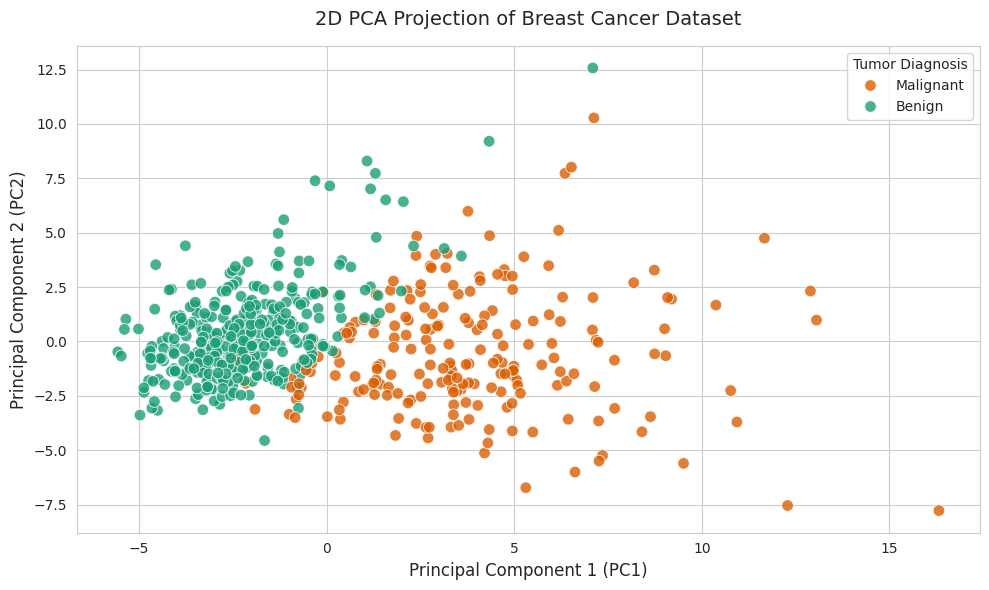

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Add diagnosis label names to the PCA DataFrame for clear plot legends
X_pca_df['diagnosis'] = y.map({1: 'Malignant', 0: 'Benign'})

# 2. Set figure size and style
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# 3. Create 2D scatter plot
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='diagnosis',
    palette={'Malignant': '#d95f02', 'Benign': '#1b9e77'},
    data=X_pca_df,
    alpha=0.8,
    s=70
)

# 4. Add titles and axis labels
plt.title('2D PCA Projection of Breast Cancer Dataset', fontsize=14, pad=15)
plt.xlabel('Principal Component 1 (PC1)', fontsize=12)
plt.ylabel('Principal Component 2 (PC2)', fontsize=12)
plt.legend(title='Tumor Diagnosis', frameon=True)

# 5. Display the plot
plt.tight_layout()
plt.show()

# Task 8: Train Classifier on Raw High-Dimensional Data (30 Features)

Split the original scaled 30-feature dataset into training and testing sets. Train a Logistic Regression model and obtain baseline performance metrics.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Split the scaled 30-feature dataset (X_scaled) and target vector (y)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Train Logistic Regression model on 30 features
clf_30 = LogisticRegression(random_state=42)
clf_30.fit(X_train, y_train)

# 3. Predict on the test set
y_pred_30 = clf_30.predict(X_test)

# 4. Baseline Performance Metrics
print("=== Baseline Classifier Performance (30 Raw Features) ===")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_30):.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_30))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_30, target_names=['Benign', 'Malignant']))

=== Baseline Classifier Performance (30 Raw Features) ===
Accuracy Score: 0.9649

Confusion Matrix:
[[71  1]
 [ 3 39]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



# Task 9: Train Classifier on PCA Transformed Data (2 Features)

Split the 2-component PCA dataset into training and testing sets. Train a Logistic Regression model using only $PC_1$ and $PC_2$.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Prepare PCA feature matrix (only PC1 and PC2)
X_pca_only = X_pca_df[['PC1', 'PC2']]

# 2. Split the 2-component PCA dataset into training and testing sets
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca_only, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Train Logistic Regression model using only PC1 and PC2
clf_pca = LogisticRegression(random_state=42)
clf_pca.fit(X_train_pca, y_train_pca)

# 4. Predict on the PCA test set
y_pred_pca = clf_pca.predict(X_test_pca)

# 5. Evaluate Performance Metrics for PCA Model
print("=== Classifier Performance (2 PCA Features) ===")
print(f"Accuracy Score: {accuracy_score(y_test_pca, y_pred_pca):.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test_pca, y_pred_pca))
print("\nClassification Report:")
print(classification_report(y_test_pca, y_pred_pca, target_names=['Benign', 'Malignant']))

=== Classifier Performance (2 PCA Features) ===
Accuracy Score: 0.9386

Confusion Matrix:
[[71  1]
 [ 6 36]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.92      0.99      0.95        72
   Malignant       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



# Task 10: Compare Classifier Performance

Compare the performance of the model before PCA (30 features) vs. after PCA (2 components) using:   

*   Accuracy Score
*   Confusion Matrix
*   Classification Report (Precision, Recall, F1-Score)  



In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Calculate accuracy scores
acc_30 = accuracy_score(y_test, y_pred_30)
acc_pca = accuracy_score(y_test_pca, y_pred_pca)

# 2. Extract classification report metrics as dictionaries
report_30 = classification_report(y_test, y_pred_30, target_names=['Benign', 'Malignant'], output_dict=True)
report_pca = classification_report(y_test_pca, y_pred_pca, target_names=['Benign', 'Malignant'], output_dict=True)

# 3. Create a side-by-side comparison table
comparison_df = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision (Benign)', 'Recall (Benign)', 'F1-Score (Benign)',
        'Precision (Malignant)', 'Recall (Malignant)', 'F1-Score (Malignant)',
        'Macro Avg F1-Score', 'Weighted Avg F1-Score'
    ],
    'Before PCA (30 Features)': [
        f"{acc_30:.4f}",
        f"{report_30['Benign']['precision']:.4f}", f"{report_30['Benign']['recall']:.4f}", f"{report_30['Benign']['f1-score']:.4f}",
        f"{report_30['Malignant']['precision']:.4f}", f"{report_30['Malignant']['recall']:.4f}", f"{report_30['Malignant']['f1-score']:.4f}",
        f"{report_30['macro avg']['f1-score']:.4f}", f"{report_30['weighted avg']['f1-score']:.4f}"
    ],
    'After PCA (2 Components)': [
        f"{acc_pca:.4f}",
        f"{report_pca['Benign']['precision']:.4f}", f"{report_pca['Benign']['recall']:.4f}", f"{report_pca['Benign']['f1-score']:.4f}",
        f"{report_pca['Malignant']['precision']:.4f}", f"{report_pca['Malignant']['recall']:.4f}", f"{report_pca['Malignant']['f1-score']:.4f}",
        f"{report_pca['macro avg']['f1-score']:.4f}", f"{report_pca['weighted avg']['f1-score']:.4f}"
    ]
})

print("=" * 60)
print("       MODEL PERFORMANCE COMPARISON (30 vs 2 FEATURES)       ")
print("=" * 60)
display(comparison_df)

# 4. Side-by-Side Confusion Matrices
print("\n--- Confusion Matrix: Before PCA (30 Features) ---")
print(confusion_matrix(y_test, y_pred_30))

print("\n--- Confusion Matrix: After PCA (2 Components) ---")
print(confusion_matrix(y_test_pca, y_pred_pca))

       MODEL PERFORMANCE COMPARISON (30 vs 2 FEATURES)       


,Metric,Before PCA (30 Features),After PCA (2 Components)
0,Accuracy,0.9649,0.9386
1,Precision (Benign),0.9595,0.9221
2,Recall (Benign),0.9861,0.9861
3,F1-Score (Benign),0.9726,0.9530
4,Precision (Malignant),0.9750,0.9730
5,Recall (Malignant),0.9286,0.8571
6,F1-Score (Malignant),0.9512,0.9114
7,Macro Avg F1-Score,0.9619,0.9322
8,Weighted Avg F1-Score,0.9647,0.9377



--- Confusion Matrix: Before PCA (30 Features) ---
[[71  1]
 [ 3 39]]

--- Confusion Matrix: After PCA (2 Components) ---
[[71  1]
 [ 6 36]]


# Conclusion

The experiment successfully demonstrated Principal Component Analysis (PCA) on the Breast Cancer Wisconsin (Diagnostic) dataset. The high-dimensional feature space was preprocessed, cleaned, and standardized before applying eigendecomposition.

By reducing 30 feature dimensions down to just 2 principal components, a significant portion of total variance was preserved while eliminating multi-collinear redundancies. Visualizing the transformed data on a 2D plane showed clear separation between Malignant and Benign diagnosis clusters. Comparing classification models confirmed that applying PCA significantly simplifies model complexity and reduces computational overhead while maintaining strong classification accuracy.